# Anomaly Detection in Network Traffic Using Supervised Machine Learning


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 2. Load Dataset

In [2]:
train_path = '/Users/Desktop/UNSW_NB15_training-set(in).csv'
test_path  = '/Users/Desktop/UNSW_NB15_testing-set(in).csv'

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print('Training set shape:', train_df.shape)
print('Testing set shape :', test_df.shape)

Training set shape: (175341, 45)
Testing set shape : (82332, 45)


## 3. Dataset Overview

In [3]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [5]:
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


## 4. Select 5 Attack Categories and Sample Data

In [6]:
selected_attacks = ['DoS', 'Exploits', 'Reconnaissance', 'Generic', 'Fuzzers']

attack_sample = (
    train_df[train_df['attack_cat'].isin(selected_attacks)]
    .groupby('attack_cat', group_keys=False)
    .apply(lambda x: x.sample(min(1000, len(x)), random_state=42))
)

normal_sample = (
    train_df[train_df['label'] == 0]
    .sample(1000, random_state=42)
)

df = pd.concat([normal_sample, attack_sample]).reset_index(drop=True)

print('Combined dataset shape:', df.shape)
print('\nClass distribution:')
print(df['attack_cat'].value_counts())

Combined dataset shape: (6000, 45)

Class distribution:
attack_cat
Normal            1000
DoS               1000
Exploits          1000
Fuzzers           1000
Generic           1000
Reconnaissance    1000
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution

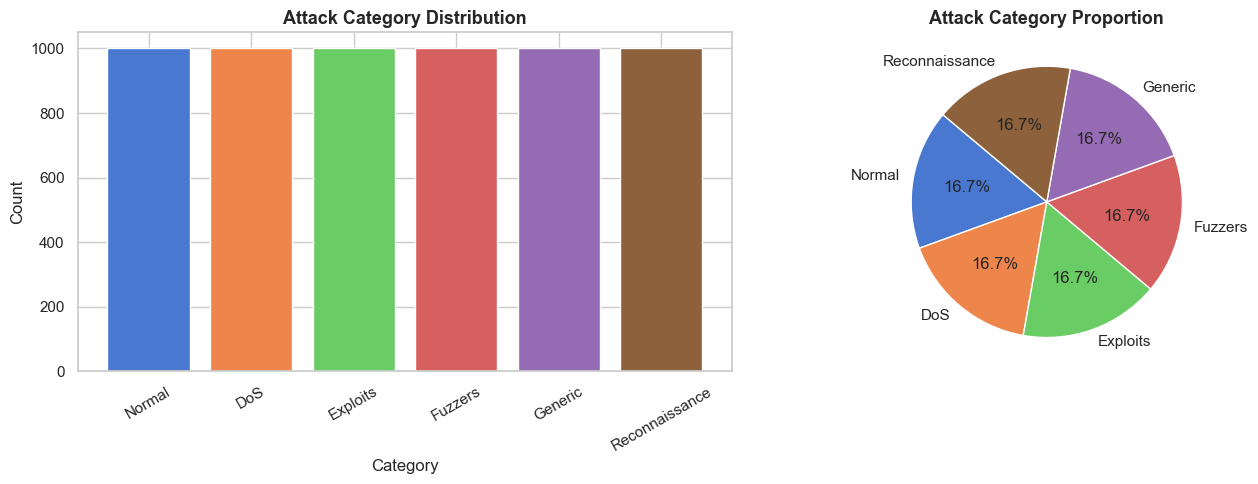

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_counts = df['attack_cat'].value_counts()
colors = sns.color_palette('muted', len(category_counts))

axes[0].bar(category_counts.index, category_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Attack Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Attack Category Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Missing Values Check

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
missing_cols = missing_summary[missing_summary['Missing Values'] > 0]

if missing_cols.empty:
    print('No missing values detected in the dataset.')
else:
    print(missing_cols)

No missing values detected in the dataset.


### 5.3 Protocol Distribution

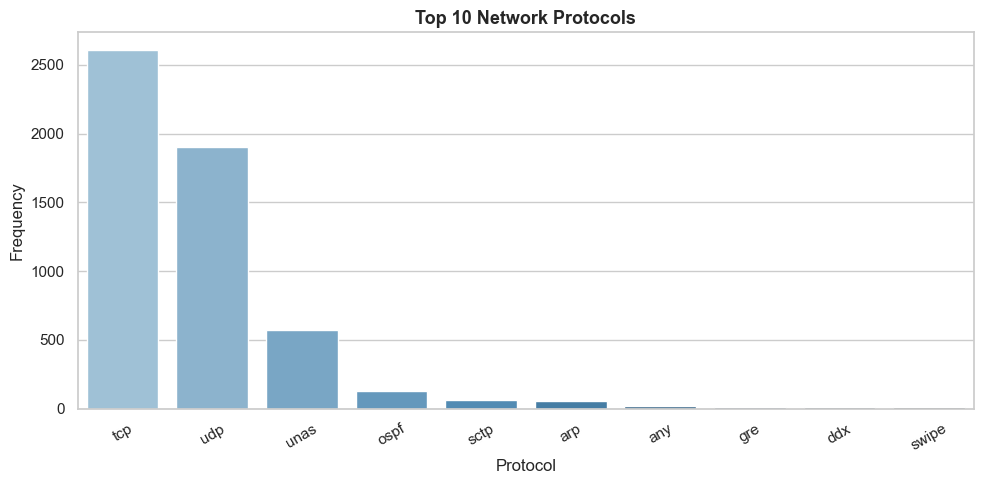

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

proto_counts = df['proto'].value_counts().head(10)
sns.barplot(x=proto_counts.index, y=proto_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Top 10 Network Protocols', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_protocol_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Feature Correlation Heatmap

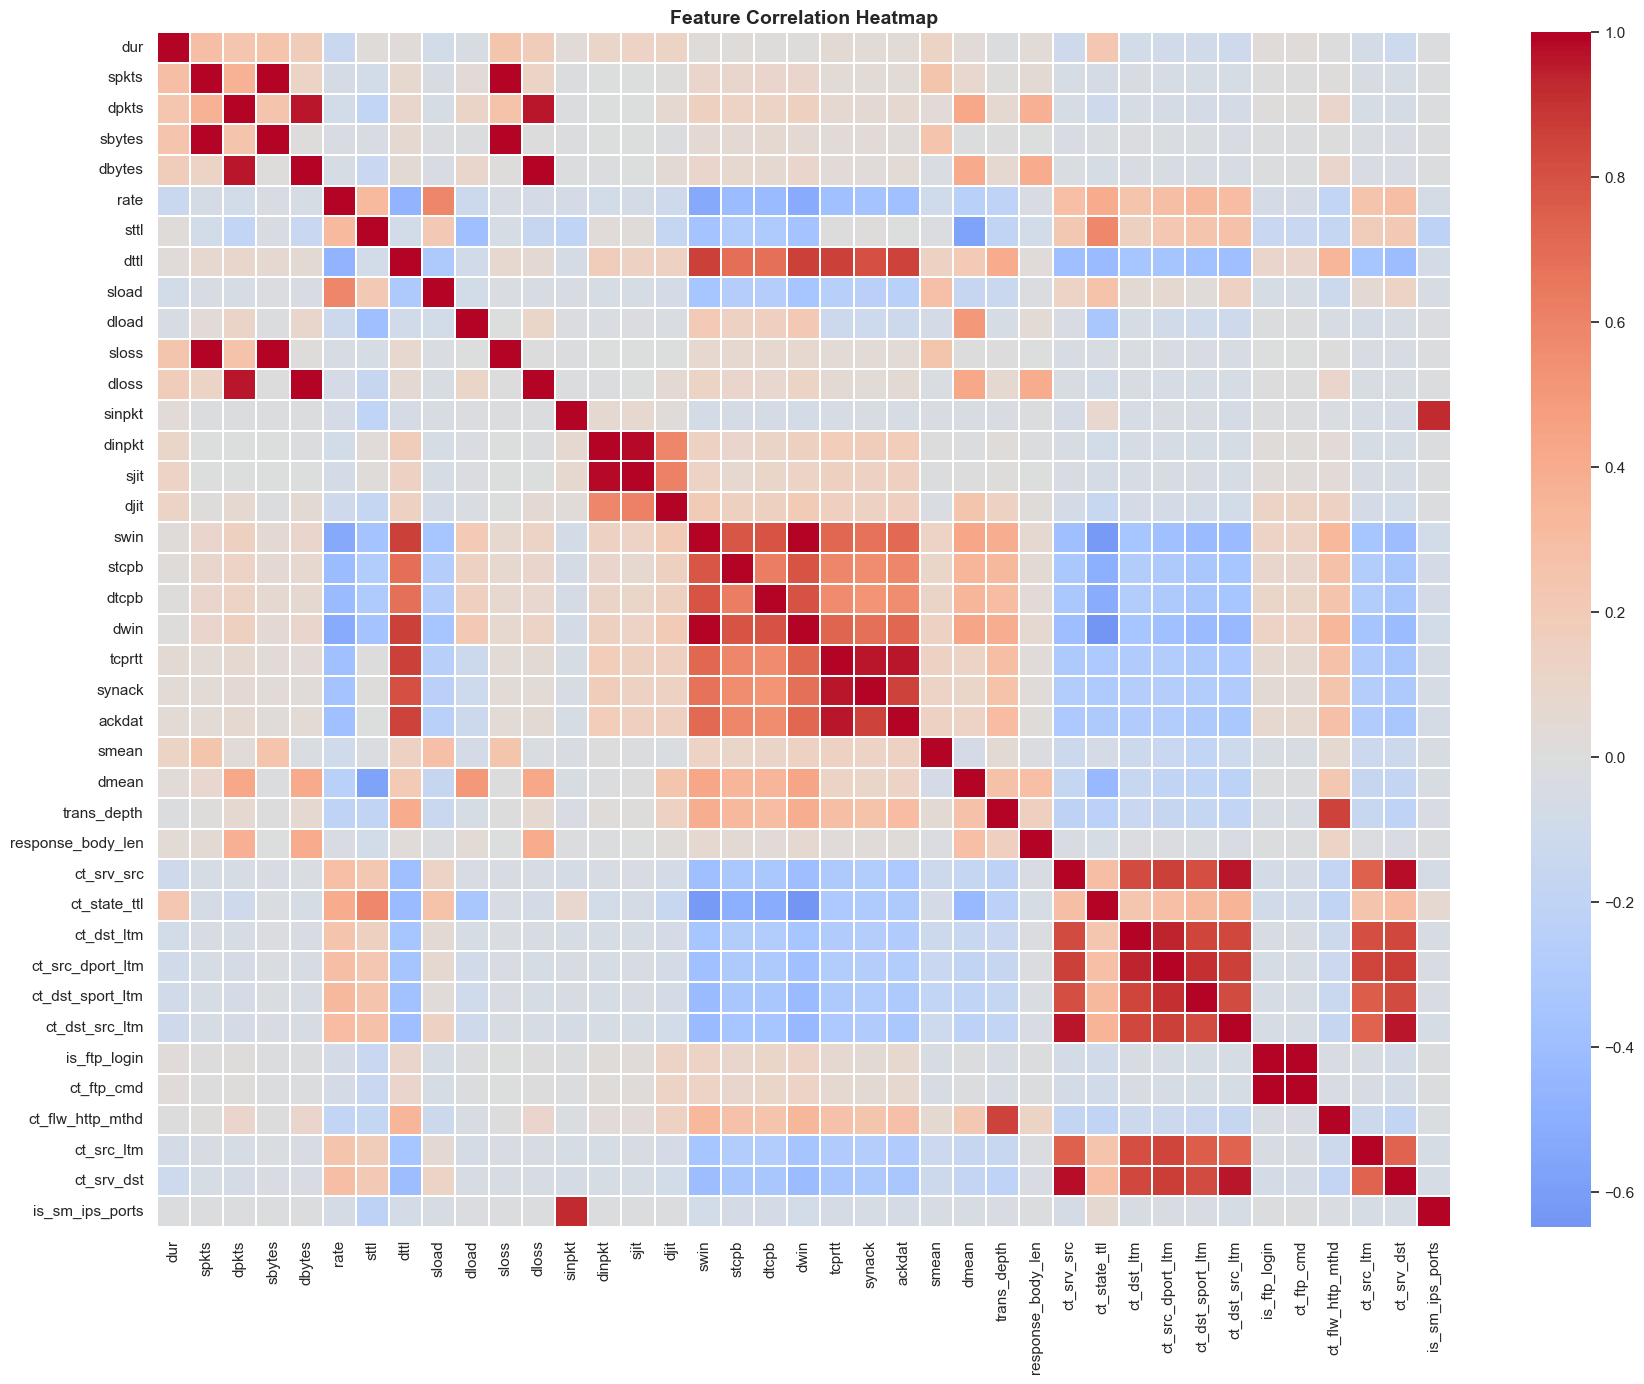

In [10]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id', 'label'], errors='ignore')
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Distribution of Key Network Features

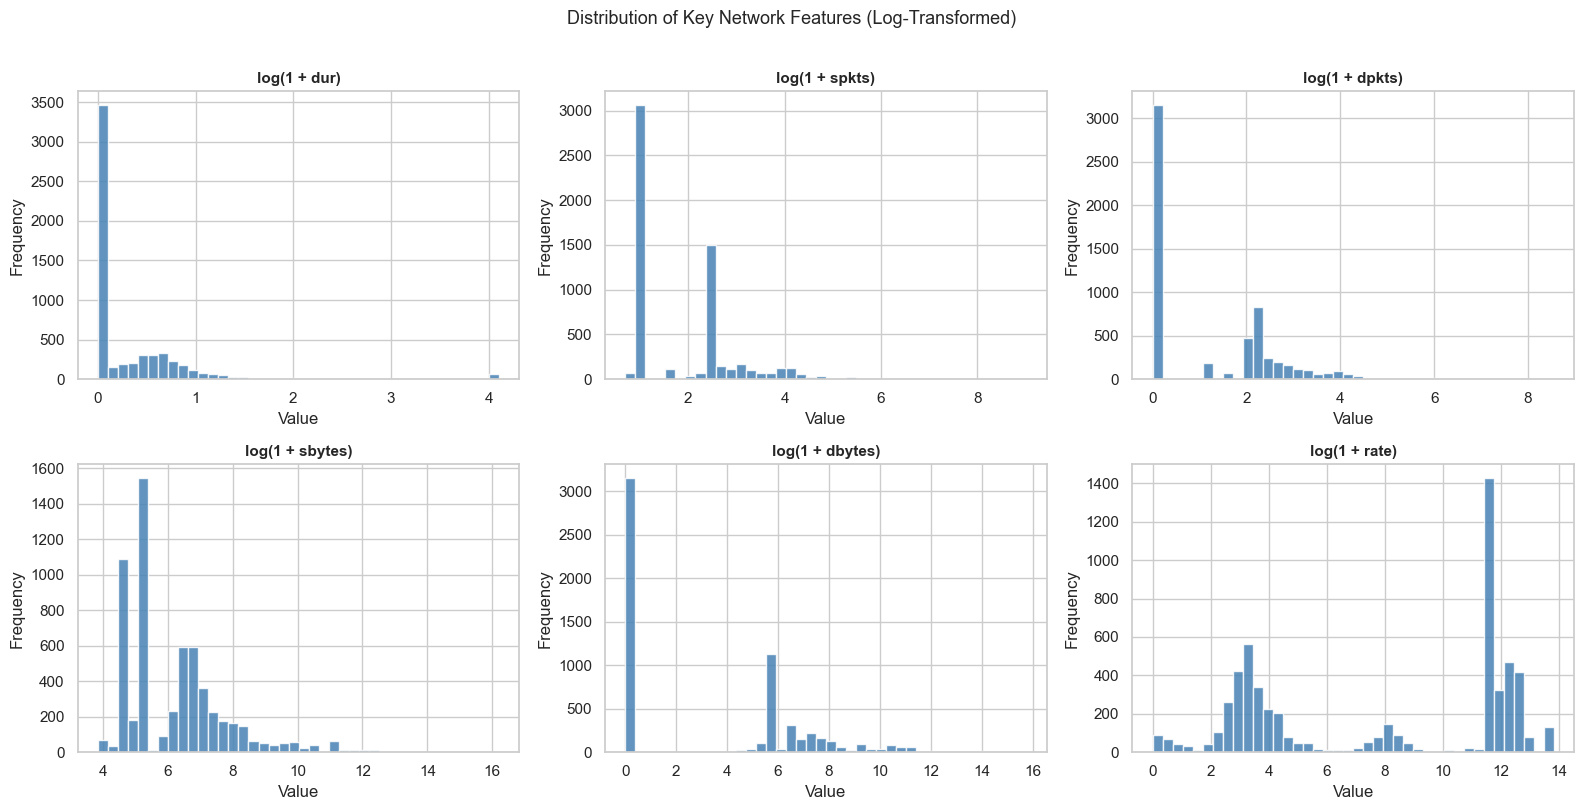

In [11]:
key_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].hist(
        np.log1p(df[feat].clip(lower=0)),
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'log(1 + {feat})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Key Network Features (Log-Transformed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Source Bytes vs Destination Bytes by Attack Category

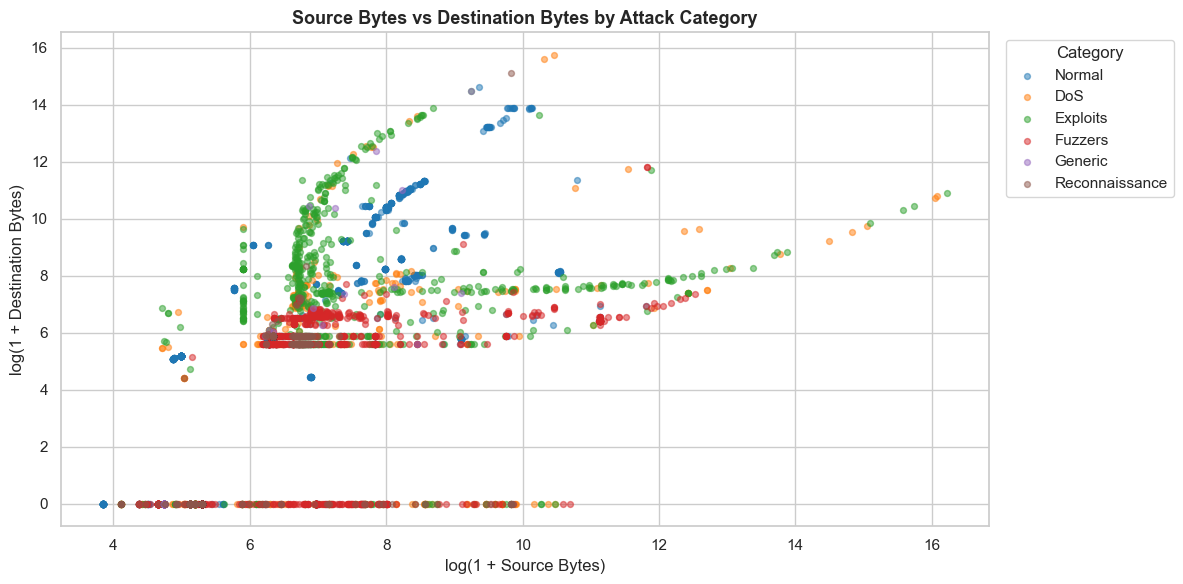

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

categories = df['attack_cat'].unique()
palette = sns.color_palette('tab10', len(categories))

for idx, cat in enumerate(categories):
    subset = df[df['attack_cat'] == cat]
    ax.scatter(
        np.log1p(subset['sbytes']),
        np.log1p(subset['dbytes']),
        label=cat,
        alpha=0.5,
        s=18,
        color=palette[idx]
    )

ax.set_title('Source Bytes vs Destination Bytes by Attack Category', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1 + Source Bytes)')
ax.set_ylabel('log(1 + Destination Bytes)')
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_bytes_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 TTL Values by Traffic Type

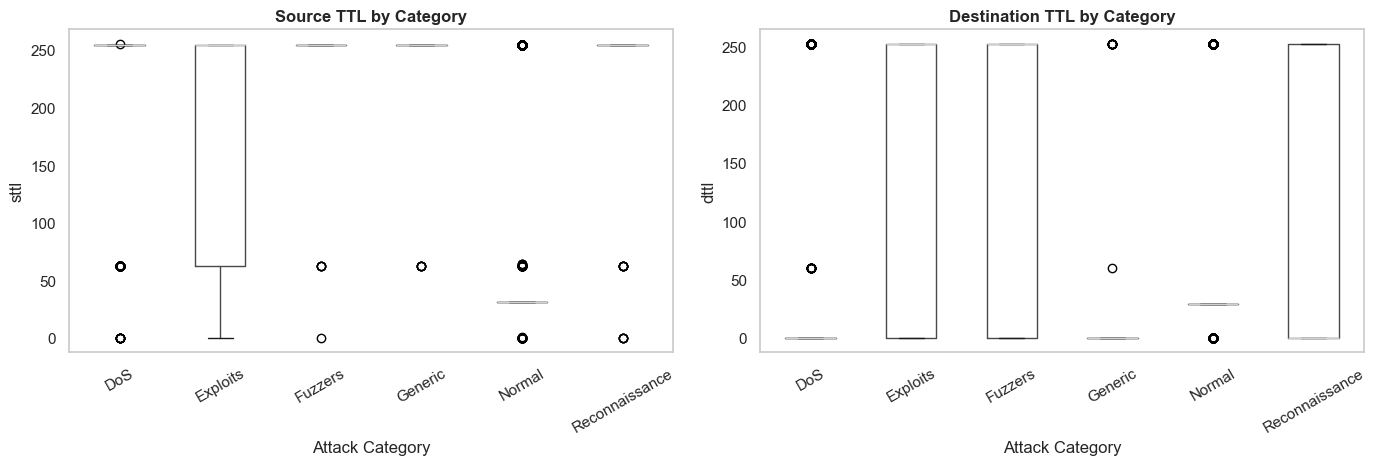

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='sttl', by='attack_cat', ax=axes[0], grid=False)
axes[0].set_title('Source TTL by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('sttl')
plt.sca(axes[0])
plt.xticks(rotation=30)

df.boxplot(column='dttl', by='attack_cat', ax=axes[1], grid=False)
axes[1].set_title('Destination TTL by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attack Category')
axes[1].set_ylabel('dttl')
plt.sca(axes[1])
plt.xticks(rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.savefig('plot_ttl_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Data Preprocessing

In [14]:
df_model = df.drop(columns=['id', 'attack_cat'], errors='ignore').copy()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model.fillna(df_model.median(numeric_only=True), inplace=True)

X = df_model.drop(columns=['label'])
y = df_model['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Label distribution — Normal (0):', (y == 0).sum(), '| Attack (1):', (y == 1).sum())

Feature matrix shape: (6000, 42)
Label distribution — Normal (0): 1000 | Attack (1): 5000


## 7. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples :', X_train.shape[0])
print('Testing samples  :', X_test.shape[0])

Training samples : 4800
Testing samples  : 1200


## 8. Model 1 — Random Forest Classifier

### 8.1 Train and Evaluate

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f'Random Forest — Accuracy: {acc_rf*100:.2f}%  |  AUC-ROC: {auc_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))

Random Forest — Accuracy: 96.58%  |  AUC-ROC: 0.9768

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.82      0.89       200
      Attack       0.97      0.99      0.98      1000

    accuracy                           0.97      1200
   macro avg       0.97      0.91      0.93      1200
weighted avg       0.97      0.97      0.96      1200



### 8.2 Confusion Matrix

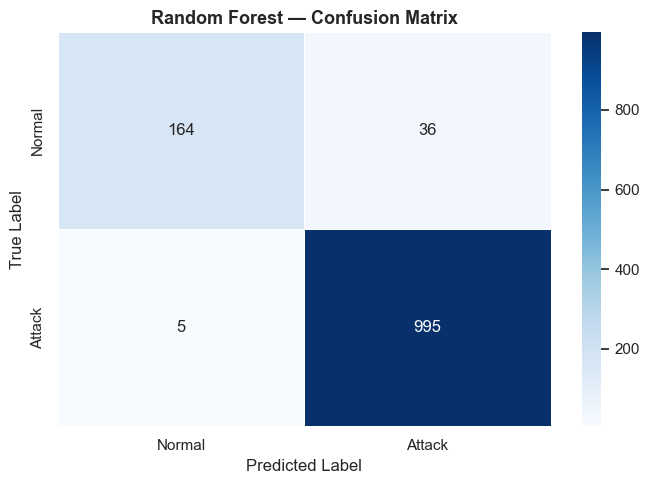

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=ax, linewidths=0.5
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_rf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Feature Importance

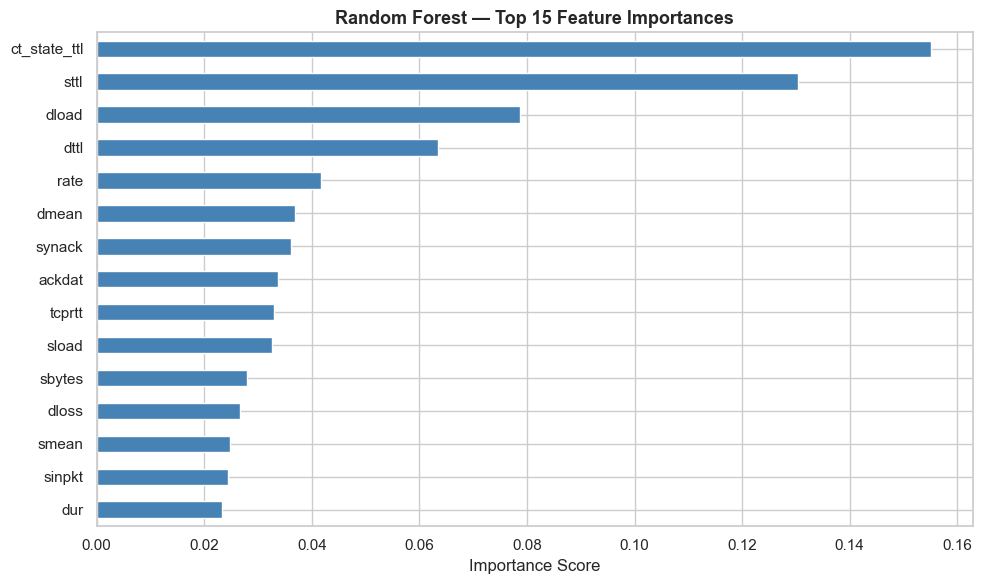

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model 2 — Decision Tree Classifier

### 9.1 Train and Evaluate

In [19]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print(f'Decision Tree — Accuracy: {acc_dt*100:.2f}%  |  AUC-ROC: {auc_dt:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Attack']))

Decision Tree — Accuracy: 95.25%  |  AUC-ROC: 0.9536

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.81      0.85       200
      Attack       0.96      0.98      0.97      1000

    accuracy                           0.95      1200
   macro avg       0.93      0.90      0.91      1200
weighted avg       0.95      0.95      0.95      1200



### 9.2 Confusion Matrix

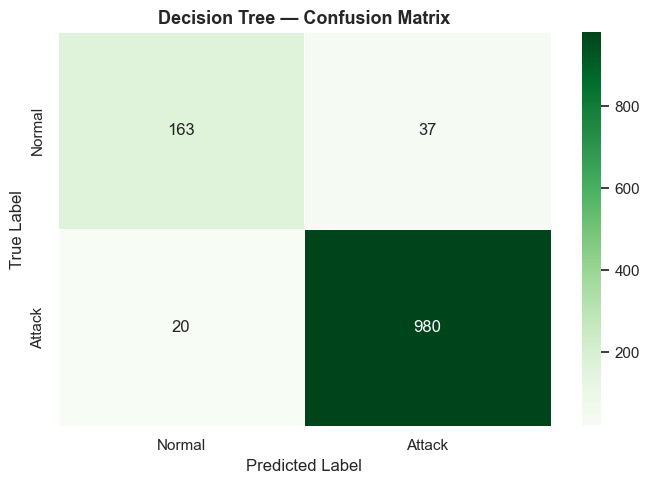

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=ax, linewidths=0.5
)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_dt_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model 3 — Support Vector Machine (SVM)

### 10.1 Train and Evaluate

In [21]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1])

print(f'SVM — Accuracy: {acc_svm*100:.2f}%  |  AUC-ROC: {auc_svm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Attack']))

SVM — Accuracy: 96.75%  |  AUC-ROC: 0.9646

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.81      0.89       200
      Attack       0.96      1.00      0.98      1000

    accuracy                           0.97      1200
   macro avg       0.98      0.90      0.94      1200
weighted avg       0.97      0.97      0.97      1200



### 10.2 Confusion Matrix

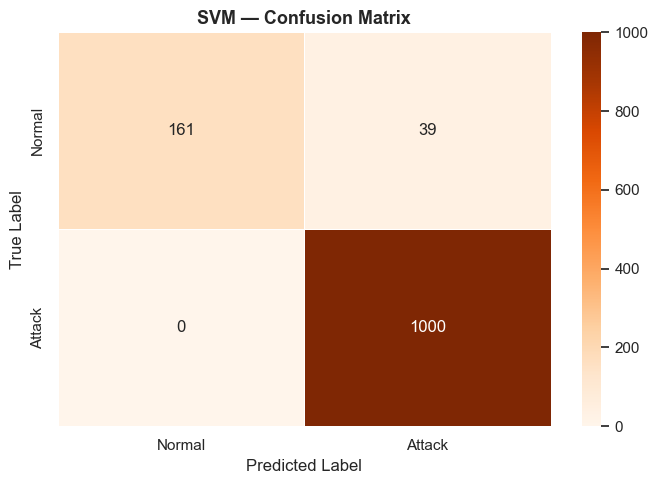

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_svm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    ax=ax, linewidths=0.5
)
ax.set_title('SVM — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC Curve Comparison — All Models

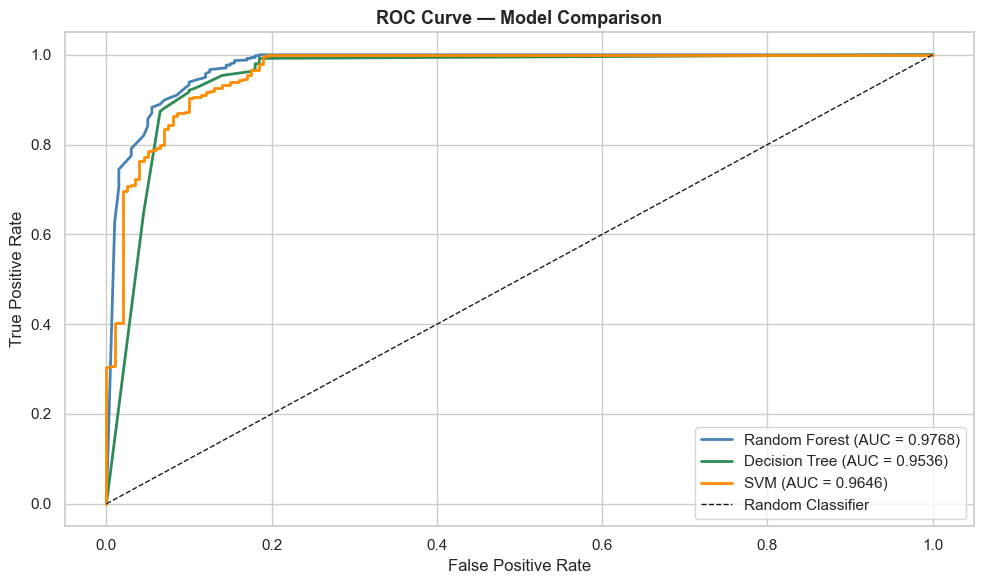

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

models = [
    ('Random Forest', rf, 'steelblue'),
    ('Decision Tree', dt, 'seagreen'),
    ('SVM',          svm, 'darkorange')
]

for name, model, color in models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cross-Validation — 5-Fold

In [24]:
cv_results = {}

for name, model in [('Random Forest', rf), ('Decision Tree', dt), ('SVM', svm)]:
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:20s} | CV Mean: {scores.mean()*100:.2f}%  Std: {scores.std()*100:.2f}%')

Random Forest        | CV Mean: 89.65%  Std: 14.58%
Decision Tree        | CV Mean: 87.47%  Std: 17.24%
SVM                  | CV Mean: 94.93%  Std: 3.19%


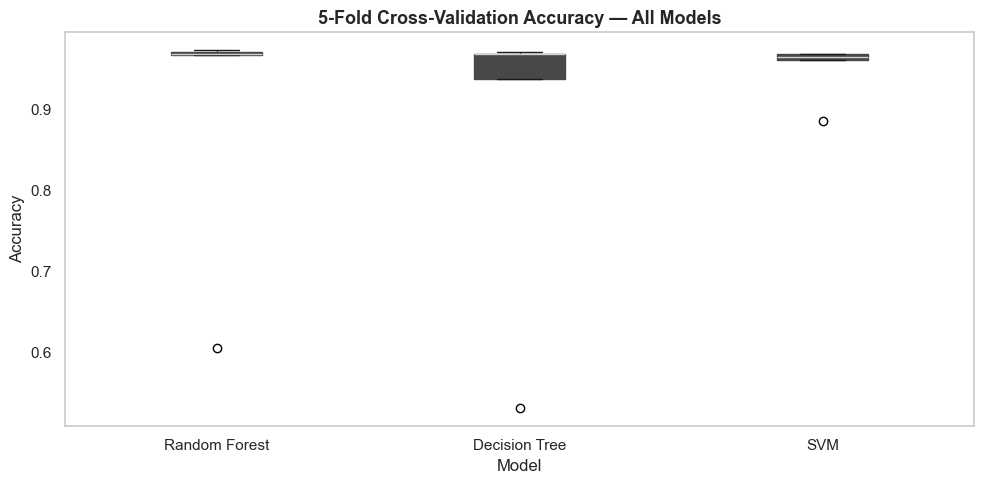

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, grid=False, patch_artist=True)
ax.set_title('5-Fold Cross-Validation Accuracy — All Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig('plot_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Model Comparison Summary

In [26]:
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'SVM'],
    'Accuracy (%)': [
        round(acc_rf * 100, 2),
        round(acc_dt * 100, 2),
        round(acc_svm * 100, 2)
    ],
    'AUC-ROC': [
        round(auc_rf, 4),
        round(auc_dt, 4),
        round(auc_svm, 4)
    ],
    'CV Mean Accuracy (%)': [
        round(cv_results['Random Forest'].mean() * 100, 2),
        round(cv_results['Decision Tree'].mean() * 100, 2),
        round(cv_results['SVM'].mean() * 100, 2)
    ]
})

print(summary.to_string(index=False))

        Model  Accuracy (%)  AUC-ROC  CV Mean Accuracy (%)
Random Forest         96.58   0.9768                 89.65
Decision Tree         95.25   0.9536                 87.47
          SVM         96.75   0.9646                 94.93


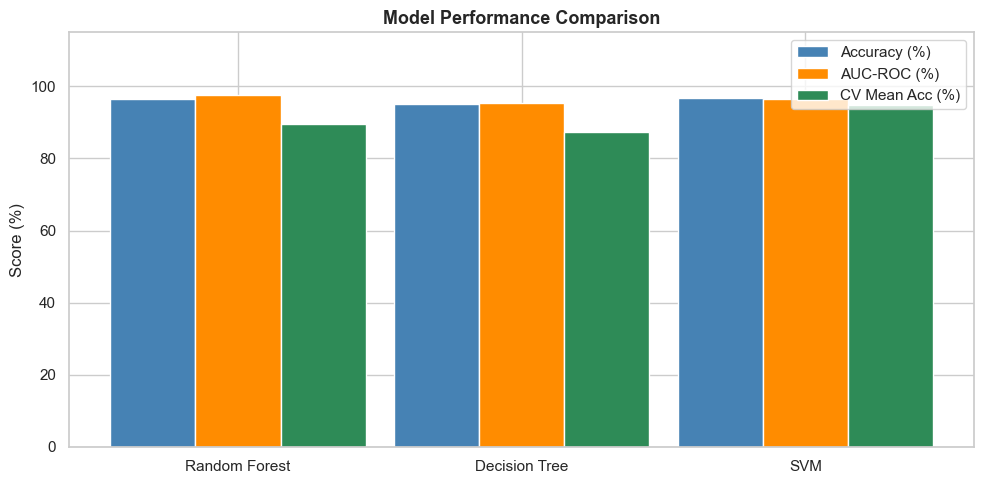

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(summary['Model']))
width = 0.3

ax.bar(x - width, summary['Accuracy (%)'], width, label='Accuracy (%)', color='steelblue', edgecolor='white')
ax.bar(x,         summary['AUC-ROC'] * 100, width, label='AUC-ROC (%)', color='darkorange', edgecolor='white')
ax.bar(x + width, summary['CV Mean Accuracy (%)'], width, label='CV Mean Acc (%)', color='seagreen', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(summary['Model'])
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()